사용할 디바이스: mps


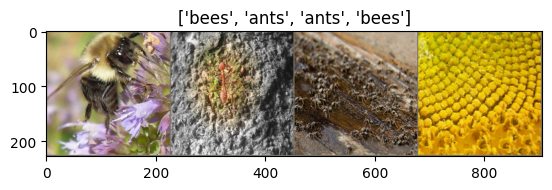

Epoch 0/24
----------
==> train Loss: 0.6284 Acc: 0.6598
==> val Loss: 0.5222 Acc: 0.7974

Epoch 1/24
----------
==> train Loss: 0.4518 Acc: 0.8443
==> val Loss: 0.3661 Acc: 0.8889

Epoch 2/24
----------
==> train Loss: 0.4094 Acc: 0.8320
==> val Loss: 0.3318 Acc: 0.8497

Epoch 3/24
----------
==> train Loss: 0.3783 Acc: 0.8525
==> val Loss: 0.2942 Acc: 0.9020

Epoch 4/24
----------
==> train Loss: 0.3720 Acc: 0.8525
==> val Loss: 0.2726 Acc: 0.9281

Epoch 5/24
----------
==> train Loss: 0.3307 Acc: 0.8525
==> val Loss: 0.2573 Acc: 0.9150

Epoch 6/24
----------
==> train Loss: 0.3434 Acc: 0.8484
==> val Loss: 0.2361 Acc: 0.9150

Epoch 7/24
----------
==> train Loss: 0.3336 Acc: 0.8811
==> val Loss: 0.2495 Acc: 0.8758

Epoch 8/24
----------
==> train Loss: 0.3670 Acc: 0.8156
==> val Loss: 0.2258 Acc: 0.9216

Epoch 9/24
----------
==> train Loss: 0.3205 Acc: 0.8525
==> val Loss: 0.2256 Acc: 0.9150

Epoch 10/24
----------
==> train Loss: 0.2764 Acc: 0.8852
==> val Loss: 0.2200 Acc: 0.9150

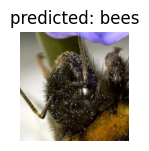

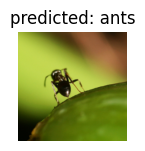

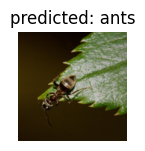

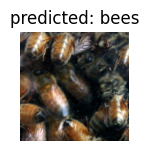

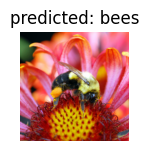

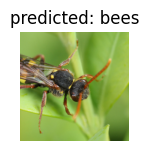

In [4]:
# 1. 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# matplotlib 인터랙티브 모드 설정
plt.ion()
# 빠른 학습을 위한 cudnn 설정
cudnn.benchmark = True

# 2. 데이터 로드 및 전처리
# 학습을 위한 데이터 증강 및 정규화
# 검증을 위한 정규화
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# 사용자의 폴더 구조에 맞게 데이터 경로 설정
# 현재 jupyter notebook 파일이 'code' 폴더 안에 있다고 가정
data_dir = '../data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}

# [수정됨 1] macOS 환경에서의 DataLoader 호환성을 위해 num_workers=0 으로 설정
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# Mac의 M 시리즈 칩(MPS) 또는 GPU, CPU 사용 설정
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")

print(f"사용할 디바이스: {device}")


# 3. 일부 학습 데이터 시각화 (옵션)
def imshow(inp, title=None):
    """텐서 형태의 이미지를 받아서 화면에 출력"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # 갱신되도록 잠시 멈춤

# 학습 데이터의 한 배치를 가져와서 시각화
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])


# 4. 모델 학습을 위한 함수 정의
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # 임시 디렉토리에 가장 좋은 모델의 가중치를 저장
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # 각 에폭(epoch)은 학습 단계와 검증 단계를 거침
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # 모델을 학습 모드로 설정
                else:
                    model.eval()   # 모델을 평가 모드로 설정

                running_loss = 0.0
                running_corrects = 0

                # 데이터를 순회
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # 파라미터 경사도를 0으로 초기화
                    optimizer.zero_grad()

                    # 순전파 (forward)
                    # 학습 시에만 연산 기록을 추적
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # 학습 단계인 경우 역전파 + 최적화
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # 통계
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                
                # [수정됨 2] MPS 장치가 float64를 지원하지 않으므로 .double()을 .float()으로 변경
                epoch_acc = running_corrects.float() / dataset_sizes[phase]

                print(f'==> {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # 모델을 깊은 복사(deep copy)하여 최고의 성능을 낸 모델을 저장
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # 가장 좋았던 모델 가중치를 로드
        model.load_state_dict(torch.load(best_model_params_path))
    return model


# 5. 예측 결과 시각화를 위한 함수 정의
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


# 6. EfficientNet-B3 모델 불러오기 및 수정
# 요구사항에 맞춰 사전학습된 efficientnet_b3 모델을 불러옵니다.
model_ft = models.efficientnet_b3(weights='IMAGENET1K_V1')

# 마지막 레이어의 입력 차원을 가져옵니다.
num_ftrs = model_ft.classifier[1].in_features

# hymenoptera 데이터셋의 클래스 수(2개)에 맞게 마지막 레이어를 수정합니다.
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# 모델을 설정한 디바이스로 이동
model_ft = model_ft.to(device)

# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# 7 에폭마다 학습률을 0.1배로 감소시키는 스케줄러
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 7. 모델 학습 및 평가 실행
# train_model 함수를 호출하여 모델 학습을 시작합니다.
# 이 과정에서 에폭별 학습 로그(손실, 정확도)가 출력됩니다.
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)

# 8. 예측 결과 시각화
# 학습이 완료된 모델로 검증 데이터셋의 예측 결과를 시각화합니다.
visualize_model(model_ft)

plt.ioff()
plt.show()

사용할 디바이스: mps
--- 시작: 시나리오 1 - 미세 조정 (Fine-tuning) ---
Epoch 0/24
----------
==> train Loss: 0.5994 Acc: 0.6844
==> val Loss: 0.4647 Acc: 0.9020

Epoch 1/24
----------
==> train Loss: 0.4787 Acc: 0.8115
==> val Loss: 0.3506 Acc: 0.9216

Epoch 2/24
----------
==> train Loss: 0.4113 Acc: 0.8525
==> val Loss: 0.2949 Acc: 0.9412

Epoch 3/24
----------
==> train Loss: 0.3879 Acc: 0.8361
==> val Loss: 0.2950 Acc: 0.9346

Epoch 4/24
----------
==> train Loss: 0.3529 Acc: 0.8484
==> val Loss: 0.2668 Acc: 0.9412

Epoch 5/24
----------
==> train Loss: 0.3569 Acc: 0.8648
==> val Loss: 0.2604 Acc: 0.9281

Epoch 6/24
----------
==> train Loss: 0.3251 Acc: 0.8607
==> val Loss: 0.2311 Acc: 0.9281

Epoch 7/24
----------
==> train Loss: 0.2919 Acc: 0.8893
==> val Loss: 0.2827 Acc: 0.9150

Epoch 8/24
----------
==> train Loss: 0.2893 Acc: 0.8893
==> val Loss: 0.2684 Acc: 0.9216

Epoch 9/24
----------
==> train Loss: 0.3405 Acc: 0.8607
==> val Loss: 0.2812 Acc: 0.9216

Epoch 10/24
----------
==> train Lo

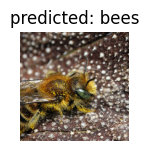

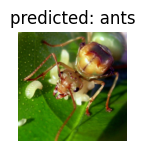

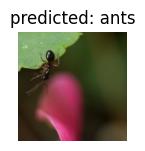

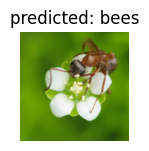

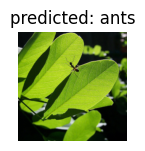

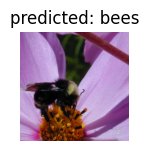


--- 시작: 시나리오 2 - 특징 추출 (Feature Extraction) ---
Epoch 0/24
----------
==> train Loss: 0.6274 Acc: 0.6311
==> val Loss: 0.5034 Acc: 0.8824

Epoch 1/24
----------
==> train Loss: 0.5058 Acc: 0.7705
==> val Loss: 0.4033 Acc: 0.8758

Epoch 2/24
----------
==> train Loss: 0.4553 Acc: 0.7951
==> val Loss: 0.3646 Acc: 0.8889

Epoch 3/24
----------
==> train Loss: 0.4301 Acc: 0.8320
==> val Loss: 0.3305 Acc: 0.8824

Epoch 4/24
----------
==> train Loss: 0.4571 Acc: 0.7623
==> val Loss: 0.3253 Acc: 0.9085

Epoch 5/24
----------
==> train Loss: 0.4697 Acc: 0.7992
==> val Loss: 0.4021 Acc: 0.8366

Epoch 6/24
----------
==> train Loss: 0.4121 Acc: 0.8156
==> val Loss: 0.3073 Acc: 0.8824

Epoch 7/24
----------
==> train Loss: 0.4030 Acc: 0.8443
==> val Loss: 0.3042 Acc: 0.9020

Epoch 8/24
----------
==> train Loss: 0.4300 Acc: 0.7787
==> val Loss: 0.3185 Acc: 0.8954

Epoch 9/24
----------
==> train Loss: 0.4222 Acc: 0.8115
==> val Loss: 0.3200 Acc: 0.8758

Epoch 10/24
----------
==> train Loss: 0.

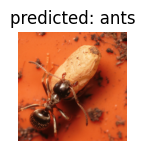

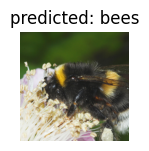

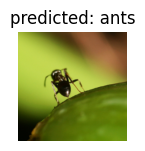

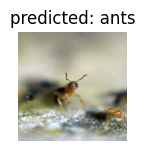

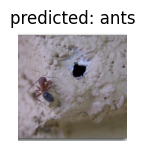

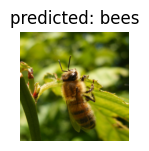

In [6]:
# 1. 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# matplotlib 인터랙티브 모드 설정
plt.ion()
# 빠른 학습을 위한 cudnn 설정
cudnn.benchmark = True

# 2. 데이터 로드 및 전처리
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '../data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print(f"사용할 디바이스: {device}")

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# 4. 모델 학습을 위한 함수 정의 (동일하게 사용)
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()
                running_loss = 0.0
                running_corrects = 0
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]
                print(f'==> {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
            print()
        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        model.load_state_dict(torch.load(best_model_params_path))
    return model

# 5. 예측 결과 시각화 함수
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])
                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

# --- 시나리오 1: 미세 조정 (Fine-tuning, 기존 방식) ---
print("--- 시작: 시나리오 1 - 미세 조정 (Fine-tuning) ---")
model_ft = models.efficientnet_b3(weights='IMAGENET1K_V1')
num_ftrs = model_ft.classifier[1].in_features
model_ft.classifier[1] = nn.Linear(num_ftrs, len(class_names))
model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()
# 옵티마이저가 model_ft.parameters(), 즉 모든 파라미터를 학습 대상으로 지정
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# 모델 학습 실행
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=25)
visualize_model(model_ft)


# --- [더 빠른 버전 추가] 시나리오 2: 특징 추출 (Feature Extraction) ---
print("\n--- 시작: 시나리오 2 - 특징 추출 (Feature Extraction) ---")
model_conv = models.efficientnet_b3(weights='IMAGENET1K_V1')

# 1. 특징 추출기 부분의 가중치를 동결(freeze)시켜 학습되지 않도록 설정
for param in model_conv.parameters():
    param.requires_grad = False

# 2. 새로 추가된 마지막 classifier 레이어의 파라미터만 학습되도록 설정
num_ftrs_conv = model_conv.classifier[1].in_features
model_conv.classifier[1] = nn.Linear(num_ftrs_conv, len(class_names))
# 새로 추가한 레이어의 파라미터들은 기본적으로 requires_grad=True 입니다.

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# 3. 옵티마이저에 학습할 파라미터(분류기 레이어)만 전달
# model_conv.classifier[1].parameters()를 전달하여 마지막 레이어만 학습하도록 지정
optimizer_conv = optim.SGD(model_conv.classifier[1].parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

# 모델 학습 실행 (학습 시간이 훨씬 짧아진 것을 확인할 수 있습니다)
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler_conv, num_epochs=25)
visualize_model(model_conv)


# 최종적으로 모든 plot을 표시
plt.ioff()
plt.show()

사용할 디바이스: mps
--- 시작: 특징 추출 (Feature Extraction) 방식 ---
Epoch 0/24
----------
==> train Loss: 0.5977 Acc: 0.6885
==> val Loss: 0.5086 Acc: 0.8039

Epoch 1/24
----------
==> train Loss: 0.4869 Acc: 0.8156
==> val Loss: 0.3969 Acc: 0.8954

Epoch 2/24
----------
==> train Loss: 0.4056 Acc: 0.8484
==> val Loss: 0.3488 Acc: 0.8758

Epoch 3/24
----------
==> train Loss: 0.4088 Acc: 0.8033
==> val Loss: 0.3262 Acc: 0.8889

Epoch 4/24
----------
==> train Loss: 0.3508 Acc: 0.8443
==> val Loss: 0.3120 Acc: 0.9085

Epoch 5/24
----------
==> train Loss: 0.3982 Acc: 0.7828
==> val Loss: 0.2826 Acc: 0.9085

Epoch 6/24
----------
==> train Loss: 0.3821 Acc: 0.8402
==> val Loss: 0.2861 Acc: 0.9216

Epoch 7/24
----------
==> train Loss: 0.3615 Acc: 0.8320
==> val Loss: 0.2958 Acc: 0.8954

Epoch 8/24
----------
==> train Loss: 0.3979 Acc: 0.8238
==> val Loss: 0.3442 Acc: 0.8627

Epoch 9/24
----------
==> train Loss: 0.3183 Acc: 0.8770
==> val Loss: 0.3541 Acc: 0.8562

Epoch 10/24
----------
==> train L

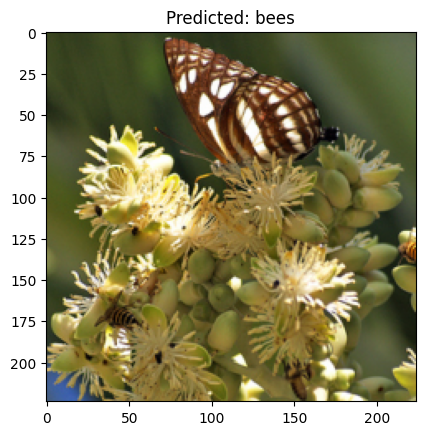

In [7]:
# 1. 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

# matplotlib 인터랙티브 모드 설정
plt.ion()
# 빠른 학습을 위한 cudnn 설정
cudnn.benchmark = True

# 2. 데이터 로드 및 전처리
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '../data/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=0)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda:0")
else:
    device = torch.device("cpu")
print(f"사용할 디바이스: {device}")

def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# 3. 모델 학습을 위한 함수 정의
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')
        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0
        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()
                running_loss = 0.0
                running_corrects = 0
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)
                    optimizer.zero_grad()
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()
                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.float() / dataset_sizes[phase]
                print(f'==> {phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)
            print()
        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')
        model.load_state_dict(torch.load(best_model_params_path))
    return model

# 4. 특정 이미지 파일 한 개에 대한 예측 시각화 함수
def visualize_model_predictions(model, img_path):
    was_training = model.training
    model.eval()
    img = Image.open(img_path).convert('RGB')
    img_transformed = data_transforms['val'](img)
    img_transformed = img_transformed.unsqueeze(0)
    img_transformed = img_transformed.to(device)
    with torch.no_grad():
        outputs = model(img_transformed)
        _, preds = torch.max(outputs, 1)
        plt.figure("Single Image Prediction")
        plt.title(f'Predicted: {class_names[preds[0]]}')
        imshow(img_transformed.cpu().data[0])
        model.train(mode=was_training)

# --- 특징 추출 (Feature Extraction) 방식 설정 및 실행 ---
print("--- 시작: 특징 추출 (Feature Extraction) 방식 ---")
model_conv = models.efficientnet_b3(weights='IMAGENET1K_V1')

# 특징 추출기 부분의 가중치를 동결(freeze)시켜 학습되지 않도록 설정
for param in model_conv.parameters():
    param.requires_grad = False

# 새로 추가된 마지막 classifier 레이어의 파라미터만 학습되도록 설정
num_ftrs_conv = model_conv.classifier[1].in_features
model_conv.classifier[1] = nn.Linear(num_ftrs_conv, len(class_names))
# 새로 추가한 레이어의 파라미터들은 기본적으로 requires_grad=True 입니다.

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# 옵티마이저에 학습할 파라미터(분류기 레이어)만 전달
optimizer_conv = optim.SGD(model_conv.classifier[1].parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler_conv = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

# 모델 학습 실행
model_conv = train_model(model_conv, criterion, optimizer_conv, exp_lr_scheduler_conv, num_epochs=25)

# 나비 사진 예측
single_image_path = '../data/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
print(f"\n--- Predicting single image: {single_image_path} ---")
visualize_model_predictions(
    model_conv,
    img_path=single_image_path
)

# 최종적으로 모든 plot을 표시
plt.ioff()
plt.show()